ML Assignment 3 – Classification

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_breast_cancer

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
from sklearn.preprocessing import StandardScaler

In [5]:
from sklearn.impute import SimpleImputer

In [6]:
from sklearn.linear_model import LogisticRegression

In [7]:
from sklearn.tree import DecisionTreeClassifier

In [8]:
from sklearn.ensemble import RandomForestClassifier

In [9]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [11]:
# Load the breast cancer dataset
cancer = load_breast_cancer()

In [12]:
# Create DataFrame
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)

In [13]:
# Create target variable
y = pd.Series(cancer.target, name="target")

In [14]:
# Display first 5 rows
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [15]:
print("Dataset Shape:", X.shape)

Dataset Shape: (569, 30)


In [16]:
print("Number of Features:", X.shape[1])

Number of Features: 30


In [17]:
print("Target Classes:", cancer.target_names)

Target Classes: ['malignant' 'benign']


In [18]:
# Check missing values
print(X.isnull().sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64


In [19]:
print("Total Missing Values:", X.isnull().sum().sum())

Total Missing Values: 0


In [20]:
print(y.value_counts())

target
1    357
0    212
Name: count, dtype: int64


In [21]:
plt.figure(figsize=(6, 4))

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<BarContainer object of 2 artists>

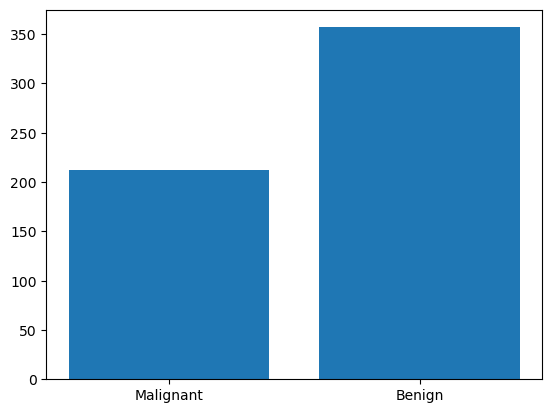

In [22]:
plt.bar(
    ["Malignant", "Benign"],
    y.value_counts().sort_index()
)

Text(0, 0.5, 'Number of Samples')

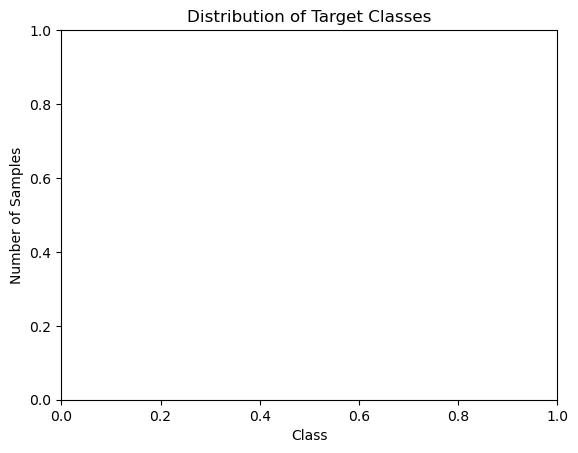

In [23]:
plt.title("Distribution of Target Classes")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

In [24]:
plt.show()

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [26]:
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (455, 30)
Testing Data: (114, 30)


In [27]:
# Create imputer
imputer = SimpleImputer(strategy="median")

In [28]:
# Fit only on training data
X_train_imputed = imputer.fit_transform(X_train)

In [29]:
# Transform test data
X_test_imputed = imputer.transform(X_test)

In [30]:
print("Missing values handled successfully.")

Missing values handled successfully.


In [31]:
# Create scaler
scaler = StandardScaler()

In [32]:
# Fit and transform training data
X_train_scaled = scaler.fit_transform(X_train_imputed)

In [33]:
# Transform test data
X_test_scaled = scaler.transform(X_test_imputed)

In [34]:
print("Feature scaling completed.")

Feature scaling completed.


In [35]:
# Create Logistic Regression model
logistic_model = LogisticRegression(max_iter=5000, random_state=42)

In [36]:
# Train the model
logistic_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [37]:
# Make predictions
logistic_pred = logistic_model.predict(X_test_scaled)

In [38]:
# Calculate accuracy
logistic_accuracy = accuracy_score(y_test, logistic_pred)

In [39]:
print("Logistic Regression Accuracy:",
      logistic_accuracy)

Logistic Regression Accuracy: 0.9824561403508771


In [40]:
# Create Decision Tree model
decision_tree = DecisionTreeClassifier(random_state=42)

In [41]:
# Train the model
decision_tree.fit(X_train_imputed, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [42]:
# Make predictions
decision_tree_pred = decision_tree.predict(X_test_imputed)

In [43]:
# Calculate accuracy
decision_tree_accuracy = accuracy_score(
    y_test,
    decision_tree_pred
)

In [44]:
print("Decision Tree Accuracy:",
      decision_tree_accuracy)

Decision Tree Accuracy: 0.9122807017543859


In [45]:
# Create Random Forest model
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [46]:
# Train the model
random_forest.fit(X_train_imputed, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [47]:
# Make predictions
random_forest_pred = random_forest.predict(X_test_imputed)

In [48]:
# Calculate accuracy
random_forest_accuracy = accuracy_score(
    y_test,
    random_forest_pred
)

In [49]:
print("Random Forest Accuracy:",
      random_forest_accuracy)

Random Forest Accuracy: 0.956140350877193


In [50]:
# Create SVM model
svm_model = SVC(random_state=42)

In [51]:
# Train the model
svm_model.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [52]:
# Make predictions
svm_pred = svm_model.predict(X_test_scaled)

In [53]:
# Calculate accuracy
svm_accuracy = accuracy_score(
    y_test,
    svm_pred
)

In [54]:
print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.9824561403508771


In [55]:
# Create k-NN model
knn_model = KNeighborsClassifier(n_neighbors=5)

In [56]:
# Train the model
knn_model.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [57]:
# Make predictions
knn_pred = knn_model.predict(X_test_scaled)

In [58]:
# Calculate accuracy
knn_accuracy = accuracy_score(
    y_test,
    knn_pred
)

In [59]:
print("k-NN Accuracy:", knn_accuracy)

k-NN Accuracy: 0.956140350877193


In [60]:
results = pd.DataFrame({
    "Algorithm": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "k-NN"
    ],
    
    "Accuracy": [
        logistic_accuracy,
        decision_tree_accuracy,
        random_forest_accuracy,
        svm_accuracy,
        knn_accuracy
    ]
})

results

,Algorithm,Accuracy
0,Logistic Regression,0.982456
1,Decision Tree,0.912281
2,Random Forest,0.956140
3,SVM,0.982456
4,k-NN,0.956140


In [61]:
results["Accuracy (%)"] = results["Accuracy"] * 100

results

,Algorithm,Accuracy,Accuracy (%)
0,Logistic Regression,0.982456,98.245614
1,Decision Tree,0.912281,91.228070
2,Random Forest,0.956140,95.614035
3,SVM,0.982456,98.245614
4,k-NN,0.956140,95.614035


In [62]:
results["Accuracy (%)"] = results["Accuracy (%)"].round(2)

results

,Algorithm,Accuracy,Accuracy (%)
0,Logistic Regression,0.982456,98.25
1,Decision Tree,0.912281,91.23
2,Random Forest,0.956140,95.61
3,SVM,0.982456,98.25
4,k-NN,0.956140,95.61


In [63]:
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<BarContainer object of 5 artists>

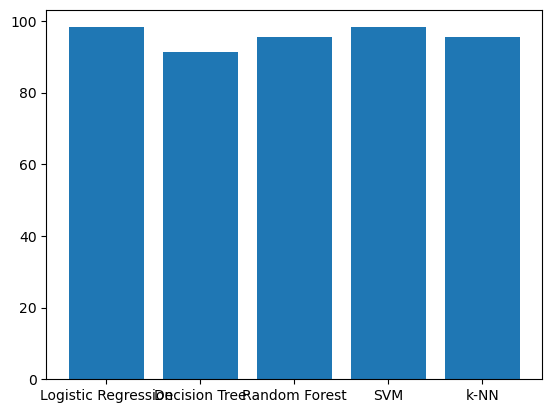

In [64]:
plt.bar(
    results["Algorithm"],
    results["Accuracy (%)"]
)

Text(0, 0.5, 'Accuracy (%)')

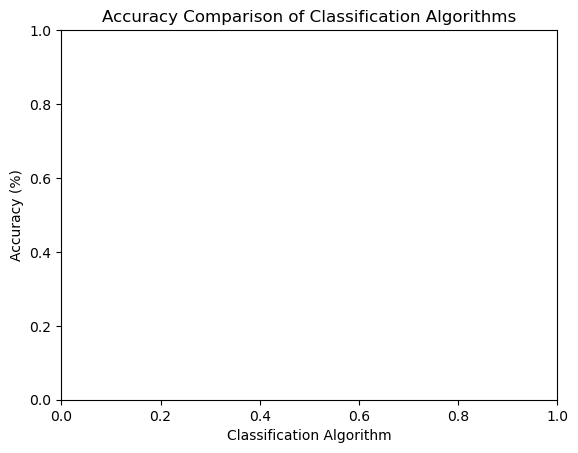

In [65]:
plt.title("Accuracy Comparison of Classification Algorithms")
plt.xlabel("Classification Algorithm")
plt.ylabel("Accuracy (%)")

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0')])

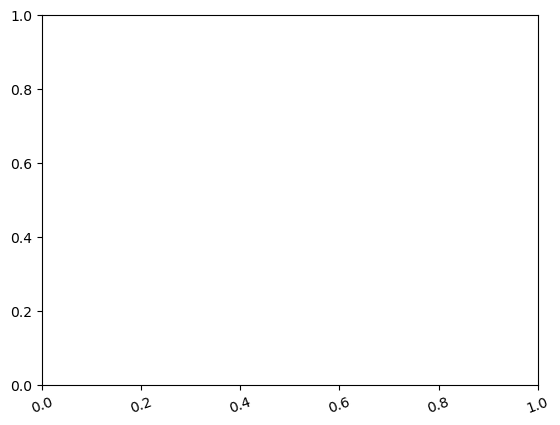

In [66]:
plt.xticks(rotation=20)

(85.0, 100.0)

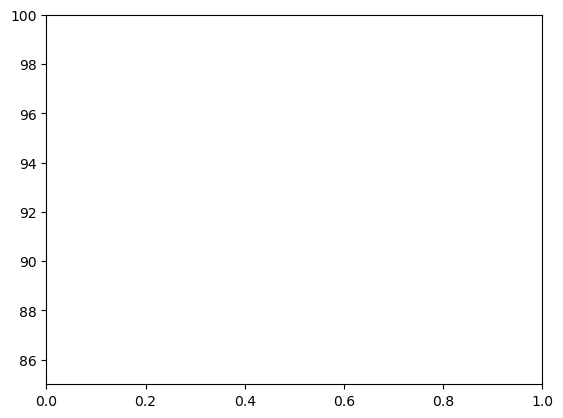

In [67]:
plt.ylim(85, 100)

In [68]:
plt.show()

In [69]:
# Calculate metrics for all models

metrics = []

predictions = {
    "Logistic Regression": logistic_pred,
    "Decision Tree": decision_tree_pred,
    "Random Forest": random_forest_pred,
    "SVM": svm_pred,
    "k-NN": knn_pred
}

In [74]:
for name, prediction in predictions.items():

    accuracy = accuracy_score(y_test, prediction)

    precision = precision_score(
        y_test,
        prediction
    )

    recall = recall_score(
        y_test,
        prediction
    )

    f1 = f1_score(
        y_test,
        prediction
    )

    metrics.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

    metrics_df = pd.DataFrame(
    metrics,
    columns=[
        "Algorithm",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

metrics_df
metrics_df.round(4)

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9825,0.9861,0.9861,0.9861
1,Decision Tree,0.9123,0.9559,0.9028,0.9286
2,Random Forest,0.9561,0.9589,0.9722,0.9655
3,SVM,0.9825,0.9861,0.9861,0.9861
4,k-NN,0.9561,0.9589,0.9722,0.9655
5,Logistic Regression,0.9825,0.9861,0.9861,0.9861
6,Decision Tree,0.9123,0.9559,0.9028,0.9286
7,Random Forest,0.9561,0.9589,0.9722,0.9655
8,SVM,0.9825,0.9861,0.9861,0.9861
9,k-NN,0.9561,0.9589,0.9722,0.9655


In [75]:
metrics_percentage = metrics_df.copy()

for column in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]:
    metrics_percentage[column] = (
        metrics_percentage[column] * 100
    ).round(2)

metrics_percentage

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,98.25,98.61,98.61,98.61
1,Decision Tree,91.23,95.59,90.28,92.86
2,Random Forest,95.61,95.89,97.22,96.55
3,SVM,98.25,98.61,98.61,98.61
4,k-NN,95.61,95.89,97.22,96.55
5,Logistic Regression,98.25,98.61,98.61,98.61
6,Decision Tree,91.23,95.59,90.28,92.86
7,Random Forest,95.61,95.89,97.22,96.55
8,SVM,98.25,98.61,98.61,98.61
9,k-NN,95.61,95.89,97.22,96.55


In [76]:
models_predictions = {
    "Logistic Regression": logistic_pred,
    "Decision Tree": decision_tree_pred,
    "Random Forest": random_forest_pred,
    "SVM": svm_pred,
    "k-NN": knn_pred
}

for name, prediction in models_predictions.items():

    cm = confusion_matrix(
        y_test,
        prediction
    )

    print("", name)
    print(cm)

 Logistic Regression
[[41  1]
 [ 1 71]]
 Decision Tree
[[39  3]
 [ 7 65]]
 Random Forest
[[39  3]
 [ 2 70]]
 SVM
[[41  1]
 [ 1 71]]
 k-NN
[[39  3]
 [ 2 70]]


In [77]:
for name, prediction in models_predictions.items():

    print("=" * 60)

    print(name)

    print("=" * 60)

    print(
        classification_report(
            y_test,
            prediction,
            target_names=cancer.target_names
        )
    )

Logistic Regression
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Decision Tree
              precision    recall  f1-score   support

   malignant       0.85      0.93      0.89        42
      benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114

Random Forest
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96   

In [78]:
best_model = metrics_df.loc[
    metrics_df["Accuracy"].idxmax()
]

worst_model = metrics_df.loc[
    metrics_df["Accuracy"].idxmin()
]

print(
    "Highest Accuracy:",
    best_model["Algorithm"],
    "-",
    round(best_model["Accuracy"] * 100, 2),
    "%"
)

Highest Accuracy: Logistic Regression - 98.25 %


In [79]:
print(
    "Lowest Accuracy:",
    worst_model["Algorithm"],
    "-",
    round(worst_model["Accuracy"] * 100, 2),
    "%"
)

Lowest Accuracy: Decision Tree - 91.23 %
